## Librerias

In [28]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, f1_score
from sklearn.model_selection import GridSearchCV, learning_curve, cross_val_score

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

## Datos

In [2]:
df = pd.read_csv('dfSegmentado.csv')

## Procesamiento

In [3]:
# 1. Separar características (X) y la variable objetivo (y)
# El 'ID' no aporta información predictiva, así que lo eliminamos.
X = df.drop(['Identificador', 'Segmento'], axis=1)
y = df['Segmento']

# 2. Codificar la variable objetivo (Segmento) a números
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Para recordar qué número es cada segmento
segment_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"Mapeo de la variable objetivo: {segment_mapping}")

Mapeo de la variable objetivo: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3)}


In [4]:
# 3. Codificar las características (X)
# Para Graduado y Estado_Civil ('Yes'/'No') usamos un mapeo simple
X['Graduado'] = X['Graduado'].map({'No': 0, 'Yes': 1})
X['Estado_Civil'] = X['Estado_Civil'].map({'No': 0, 'Yes': 1})

# Para Puntuacion_Gasto le damos un orden
X['Puntuacion_Gasto'] = X['Puntuacion_Gasto'].map({'Low': 0, 'Average': 1, 'High': 2})

# Para Género y Profesión usamos pd.get_dummies
X_encoded = pd.get_dummies(X, columns=['Genero', 'Profesion'], drop_first=True)

print("Datos preparados para el entrenamiento.")
X_encoded.head()

Datos preparados para el entrenamiento.


,Estado_Civil,Edad,Graduado,Experiencia_Laboral,Puntuacion_Gasto,Tamano_Familiar,Genero_Male,Profesion_Doctor,Profesion_Engineer,Profesion_Entertainment,Profesion_Executive,Profesion_Healthcare,Profesion_Homemaker,Profesion_Lawyer,Profesion_Marketing
0,0,22,0,1.0,0,4.0,True,False,False,False,False,True,False,False,False
1,1,38,1,1.0,1,3.0,False,False,True,False,False,False,False,False,False
2,1,67,1,1.0,0,1.0,False,False,True,False,False,False,False,False,False
3,1,67,1,0.0,2,2.0,True,False,False,False,False,False,False,True,False
4,1,40,1,1.0,2,6.0,False,False,False,True,False,False,False,False,False


## Modelo - Árbol de Decisión

In [5]:
# 1. Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

In [6]:
# --- Modelo 1: Árbol de Decisión ---
print("--- Entrenando Árbol de Decisión ---")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predicciones Árbol de Decisión
y_pred_dt = dt_model.predict(X_test)

--- Entrenando Árbol de Decisión ---


In [7]:
# Evaluación Árbol de Decisión
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Exactitud (Accuracy) Árbol de Decisión: {accuracy_dt:.4f}")
print("Reporte de Clasificación (Árbol de Decisión):")
print(classification_report(y_test, y_pred_dt, target_names=label_encoder.classes_))

Exactitud (Accuracy) Árbol de Decisión: 0.4250
Reporte de Clasificación (Árbol de Decisión):
              precision    recall  f1-score   support

           A       0.35      0.35      0.35       391
           B       0.30      0.34      0.32       369
           C       0.44      0.41      0.42       380
           D       0.60      0.57      0.58       474

    accuracy                           0.43      1614
   macro avg       0.42      0.42      0.42      1614
weighted avg       0.43      0.43      0.43      1614



## Modelo - Random Forest

In [8]:
print("\n--- Entrenando Random Forest ---")
# n_estimators=100 significa que usará 100 árboles
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predicciones Random Forest
y_pred_rf = rf_model.predict(X_test)


--- Entrenando Random Forest ---


In [9]:
# Evaluación Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Exactitud (Accuracy) Random Forest: {accuracy_rf:.4f}")
print("Reporte de Clasificación (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Exactitud (Accuracy) Random Forest: 0.4641
Reporte de Clasificación (Random Forest):
              precision    recall  f1-score   support

           A       0.36      0.35      0.36       391
           B       0.33      0.33      0.33       369
           C       0.48      0.49      0.48       380
           D       0.63      0.64      0.64       474

    accuracy                           0.46      1614
   macro avg       0.45      0.45      0.45      1614
weighted avg       0.46      0.46      0.46      1614



In [10]:

# # Binarizar las etiquetas de prueba para multiclase
# y_test_bin = label_binarize(y_test, classes=np.arange(len(label_encoder.classes_)))

# # Probabilidades del modelo optimizado
# y_score = mejor_rf.predict_proba(X_test)

# n_classes = y_test_bin.shape[1]

# fpr = {}
# tpr = {}
# roc_auc = {}

# for i in range(n_classes):
#     fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
#     roc_auc[i] = auc(fpr[i], tpr[i])

# # Promedios micro y macro
# fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
# roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
# mean_tpr = np.zeros_like(all_fpr)
# for i in range(n_classes):
#     mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
# mean_tpr /= n_classes

# fpr["macro"] = all_fpr
# tpr["macro"] = mean_tpr
# roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# plt.figure(figsize=(8, 6))
# colors = sns.color_palette("tab10", n_classes)

# for i, color in zip(range(n_classes), colors):
#     plt.plot(fpr[i], tpr[i], color=color,
#              label=f"Clase {label_encoder.classes_[i]} (AUC = {roc_auc[i]:.2f})")

# plt.plot(fpr["micro"], tpr["micro"], color="deeppink", linestyle=":", linewidth=2,
#          label=f"Micro-average (AUC = {roc_auc['micro']:.2f})")
# plt.plot(fpr["macro"], tpr["macro"], color="navy", linestyle=":", linewidth=2,
#          label=f"Macro-average (AUC = {roc_auc['macro']:.2f})")

# plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.75)
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel("Tasa de Falsos Positivos")
# plt.ylabel("Tasa de Verdaderos Positivos")
# plt.title("Curvas ROC Multiclase - Random Forest Optimizado")
# plt.legend(loc="lower right", fontsize="small")
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

## Comparacion

In [11]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Decision Tree Accuracy: 0.4250309789343247
Random Forest Accuracy: 0.46406443618339527


## Importancia de las variables en el Random Forest

C:\Users\Usuario\AppData\Local\Temp\ipykernel_18360\1476110516.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='viridis')


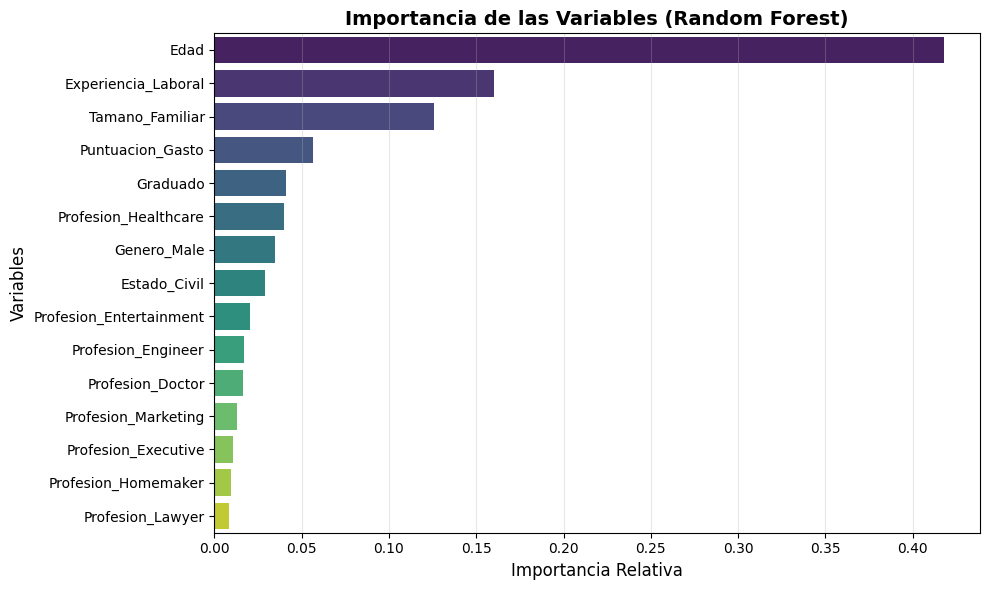

Top 5 variables más importantes:
           Variable  Importancia
               Edad     0.417697
Experiencia_Laboral     0.160007
    Tamano_Familiar     0.125904
   Puntuacion_Gasto     0.056603
           Graduado     0.040807


In [12]:
# Obtener la importancia de las características
importancias = rf_model.feature_importances_
columnas = X_train.columns

# Crear un DataFrame para ordenar y visualizar mejor
df_importancias = pd.DataFrame({
    'Variable': columnas, 
    'Importancia': importancias
})
# Ordenar de mayor a menor importancia
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='viridis')
plt.title('Importancia de las Variables (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Imprimir el top 5 en texto
print("Top 5 variables más importantes:")
print(df_importancias.head(5).to_string(index=False))

## Optimizacion de Random Forest

In [13]:
print("--- Buscando los mejores hiperparámetros para Random Forest ---")
print("Esto puede tardar uno o dos minutos...")

# Definir la "cuadrícula" de parámetros a probar
param_grid = {
    'n_estimators': [100, 200],         # Cantidad de árboles
    'max_depth': [5, 10, 15, None],     # Profundidad máxima (evita sobreajuste)
    'min_samples_split': [2, 10, 20],   # Mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 5, 10]      # Mínimo de muestras en hojas finales
}

# Inicializar un nuevo Random Forest base
rf_base = RandomForestClassifier(random_state=42)

# Configurar GridSearchCV (prueba todas las combinaciones usando validación cruzada cv=3)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=1, scoring='accuracy')

# Ejecutar el entrenamiento
grid_search.fit(X_train, y_train)

# Ver resultados
print(f"\n¡Búsqueda terminada!")
print(f"Mejores parámetros encontrados:\n{grid_search.best_params_}")

--- Buscando los mejores hiperparámetros para Random Forest ---
Esto puede tardar uno o dos minutos...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

¡Búsqueda terminada!
Mejores parámetros encontrados:
{'max_depth': 15, 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 200}


In [14]:
# Evaluar el modelo optimizado con los datos de prueba
mejor_rf = grid_search.best_estimator_
y_pred_optimizado = mejor_rf.predict(X_test)
accuracy_opt = accuracy_score(y_test, y_pred_optimizado)

print(f"\nExactitud (Accuracy) del Random Forest Optimizado: {accuracy_opt:.4f}")


Exactitud (Accuracy) del Random Forest Optimizado: 0.5186


## Matriz de confusion - Random Forest Optimizado

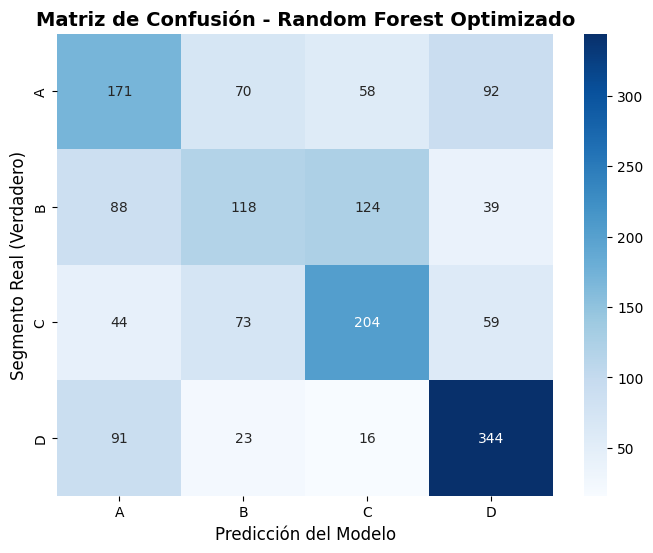

In [15]:
# Calcular la matriz de confusión con las predicciones del modelo optimizado
cm = confusion_matrix(y_test, y_pred_optimizado)

# Crear el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)

plt.title('Matriz de Confusión - Random Forest Optimizado', fontsize=14, fontweight='bold')
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Segmento Real (Verdadero)', fontsize=12)
plt.show()

## Grafico: ROC

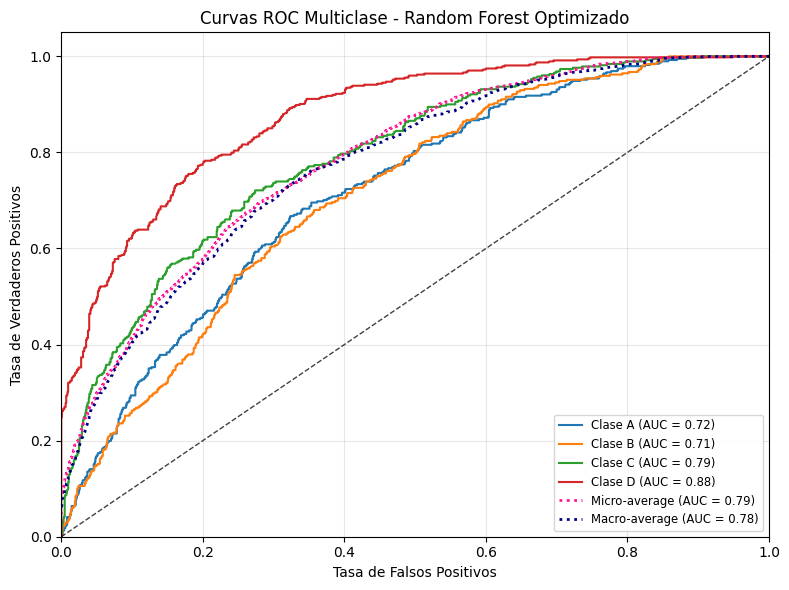

In [17]:

# Binarizar las etiquetas de prueba para multiclase
y_test_bin = label_binarize(y_test, classes=np.arange(len(label_encoder.classes_)))

# Probabilidades del modelo optimizado
y_score = mejor_rf.predict_proba(X_test)

n_classes = y_test_bin.shape[1]

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Promedios micro y macro
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8, 6))
colors = sns.color_palette("tab10", n_classes)

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f"Clase {label_encoder.classes_[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot(fpr["micro"], tpr["micro"], color="deeppink", linestyle=":", linewidth=2,
         label=f"Micro-average (AUC = {roc_auc['micro']:.2f})")
plt.plot(fpr["macro"], tpr["macro"], color="navy", linestyle=":", linewidth=2,
         label=f"Macro-average (AUC = {roc_auc['macro']:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.75)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curvas ROC Multiclase - Random Forest Optimizado")
plt.legend(loc="lower right", fontsize="small")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Underfitting vs Overfitting

In [18]:
# Evaluamos Train vs Test para detectar Overfitting/Underfitting
train_preds = mejor_rf.predict(X_train)
test_preds = mejor_rf.predict(X_test)

print(f"Accuracy Entrenamiento (RF Optimizado): {accuracy_score(y_train, train_preds):.4f}")
print(f"Accuracy Prueba (RF Optimizado): {accuracy_score(y_test, test_preds):.4f}")

Accuracy Entrenamiento (RF Optimizado): 0.5872
Accuracy Prueba (RF Optimizado): 0.5186


La diferencia (gap) entre ambos es de apenas ~6.8%. Esto es una gran noticia respecto al Overfitting; significa que con la optimización se logro controlar al Random Forest y ya no está memorizando ruido. Sin embargo, como el accuracy de entrenamiento no supera el 58%, el diagnóstico principal es Underfitting (Alto Sesgo).

Conclusión: El modelo le falta capacidad (o le falta información en las variables) para entender todas las reglas complejas que diferencian a un cliente del segmento A de uno del segmento D.

## Curvas de Aprendizaje

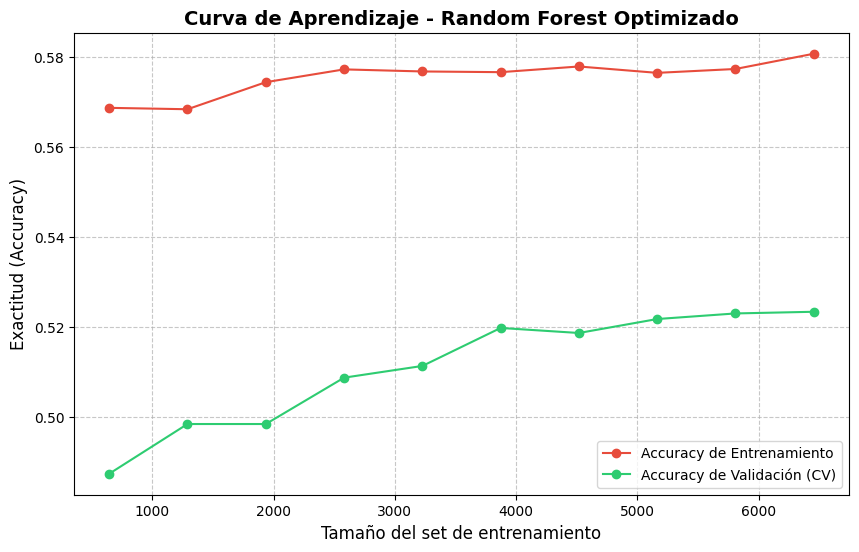

In [31]:
# Calculamos la curva usando el modelo optimizado y los datos codificados
train_sizes, train_scores, test_scores = learning_curve(
    mejor_rf, X_encoded, y_encoded, cv=5, 
    scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# promedios
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="#e74c3c", label='Accuracy de Entrenamiento')
plt.plot(train_sizes, test_mean, 'o-', color="#2ecc71", label='Accuracy de Validación (CV)')

plt.title('Curva de Aprendizaje - Random Forest Optimizado', fontsize=14, fontweight='bold')
plt.xlabel('Tamaño del set de entrenamiento', fontsize=12)
plt.ylabel('Exactitud (Accuracy)', fontsize=12)
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Al ver el comportamiento numérico, la gráfica muestra cómo la línea de entrenamiento y la de validación convergen cerca la una de la otra, creando un "techo" alrededor del 0.52.

Conclusión de la curva: Cuando las líneas se juntan y se aplanan en un valor bajo, nos dice que conseguir más filas (más clientes) no va a mejorar el modelo. Llegamos al límite de lo que estas columnas específicas pueden enseñar.

## Cross-Validation

In [21]:
# Validación Cruzada (K-Fold CV)

# Usamos el modelo optimizado y los datos que ya pasaron por get_dummies y mapeos
scores = cross_val_score(mejor_rf, X_encoded, y_encoded, cv=5, scoring='accuracy')

print(f"Scores de cada fold: {scores}")
print(f"Accuracy promedio (CV=5): {scores.mean():.4f}")
print(f"Desviación estándar: {scores.std():.4f}")

Scores de cada fold: [0.53407683 0.51920694 0.5173482  0.53254805 0.51394916]
Accuracy promedio (CV=5): 0.5234
Desviación estándar: 0.0083


Esa desviación de 0.0083 (menos del 1%) es muy buena en términos de estabilidad. Significa que el modelo es súper consistente. Le pases los datos que le pases, va a acertar un ~52% de las veces, ni más ni menos. Confirma matemáticamente que tu 51.8% del test no fue producto del azar en la división de datos, sino que es el verdadero poder predictivo de tu dataset actual.

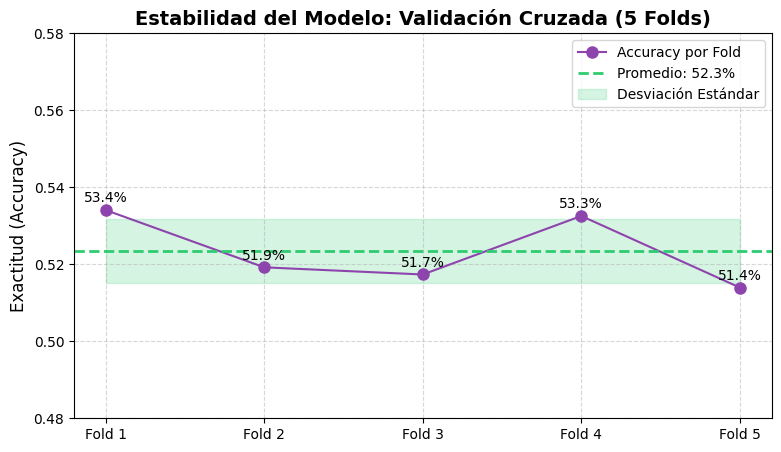

In [ ]:

# scores = cross_val_score(mejor_rf, X_encoded, y_encoded, cv=5)
folds = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']

plt.figure(figsize=(9, 5))

# Graficamos los scores de cada fold como puntos conectados
plt.plot(folds, scores, marker='o', linestyle='-', color='#8e44ad', markersize=8, label='Accuracy por Fold')

# Añadimos una línea horizontal para el promedio
media_cv = scores.mean()
plt.axhline(y=media_cv, color='#2ecc71', linestyle='--', linewidth=2, label=f'Promedio: {media_cv*100:.1f}%')

# Rellenar el área de la desviación estándar (opcional pero se ve muy pro)
std_cv = scores.std()
plt.fill_between(folds, media_cv - std_cv, media_cv + std_cv, color='#2ecc71', alpha=0.2, label='Desviación Estándar')

# Etiquetas de datos en cada punto
for i, score in enumerate(scores):
    plt.text(i, score + 0.002, f"{score*100:.1f}%", ha='center', fontsize=10)

plt.title('Estabilidad del Modelo: Validación Cruzada (5 Folds)', fontsize=14, fontweight='bold')
plt.ylabel('Exactitud (Accuracy)', fontsize=12)
plt.ylim(0.48, 0.58) # Zoom al área relevante
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## F1 Macro

In [23]:
report_f1 = classification_report(
    y_test,
    y_pred_optimizado,
    target_names=label_encoder.classes_,
    output_dict=True
)

for clase in label_encoder.classes_:
    print(f"F1 {clase}: {report_f1[clase]['f1-score']:.4f}")

print(f"F1 Macro: {report_f1['macro avg']['f1-score']:.4f}")

F1 A: 0.4357
F1 B: 0.3614
F1 C: 0.5217
F1 D: 0.6825
F1 Macro: 0.5003


El modelo no se equivoca por igual en todas partes.

* Segmento D (0.6825) - Modelo es bastante decente identificando a los clientes del segmento D. Esto significa que este grupo tiene características muy marcadas y distintas al resto (quizás edades muy específicas o un patrón de gastos muy claro).

* Segmento C (0.5217) - El rendimiento aquí es promedio. Acierta la mitad de las veces.

* Segmento A (0.4357) y Segmento B (0.3614) - Aquí radica el problema central del modelo. Le cuesta muchísimo distinguir a los clientes del grupo B y A. Es muy probable que estos dos segmentos compartan características similares en las columnas del dataset (misma profesión, mismo estado civil, etc.), por lo que el algoritmo de Random Forest no encuentra la "regla" matemática para separarlos.

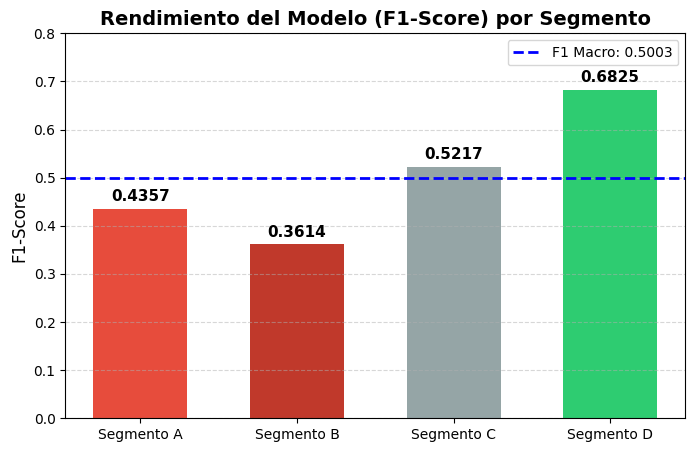

In [24]:
segmentos = ['Segmento A', 'Segmento B', 'Segmento C', 'Segmento D']
f1_scores = [0.4357, 0.3614, 0.5217, 0.6825]
f1_macro = 0.5003

plt.figure(figsize=(8, 5))
# Colores: Rojo para los peores, verde para el mejor, gris para el medio
colores = ['#e74c3c', '#c0392b', '#95a5a6', '#2ecc71']

barras = plt.bar(segmentos, f1_scores, color=colores, width=0.6)

# Añadir el valor sobre las barras
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.01, f"{yval:.4f}", 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# Línea del F1 Macro
plt.axhline(y=f1_macro, color='blue', linestyle='--', linewidth=2, label=f'F1 Macro: {f1_macro:.4f}')

plt.title('Rendimiento del Modelo (F1-Score) por Segmento', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0, 0.8) # Límite Y para acomodar etiquetas
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Resumen Metricas

In [30]:
# 1. Generar predicciones
train_preds = mejor_rf.predict(X_train)
test_preds = mejor_rf.predict(X_test)

# 2. Calcular Accuracy
acc_train = accuracy_score(y_train, train_preds)
acc_test = accuracy_score(y_test, test_preds)

# 3. Calcular Validación Cruzada (CV=5)
cv_scores = cross_val_score(mejor_rf, X_encoded, y_encoded, cv=5, scoring='accuracy', n_jobs=-1)
cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

# 4. Calcular F1-Scores (Macro y por Clase)
f1_macro = f1_score(y_test, test_preds, average='macro')
f1_por_clase = f1_score(y_test, test_preds, average=None) 

# 5. Definir las descripciones para cada métrica
descripciones = [
    "Rendimiento sobre los datos de aprendizaje. Refleja qué tanto logró ajustarse el algoritmo.",
    "Rendimiento real sobre clientes nuevos. Confirma el poder predictivo actual.",
    "Brecha de generalización. Al ser baja, confirma que no hay memorización (ausencia de Overfitting).",
    "Acierto promedio al evaluar el modelo en 5 divisiones distintas de todo el dataset.",
    "Variabilidad de los aciertos. Un valor cercano a 0 (ej. <0.01) demuestra que el modelo es muy estable.",
    "Promedio equitativo del éxito en todos los segmentos. Confirma el rendimiento global del ~50%.",
    "Rendimiento deficiente. Al algoritmo le cuesta encontrar un patrón claro para este grupo.",
    "El punto ciego del modelo. Es el perfil de cliente que más se confunde con los demás.",
    "Rendimiento medio. Logra identificar aproximadamente a la mitad de este grupo correctamente.",
    "El segmento mejor definido. Las características de estos clientes son muy distintivas y fáciles de predecir."
]

# 6. Consolidar en un DataFrame
resumen_metricas = {
    "Métrica (Diagnóstico)": [
        "Accuracy Entrenamiento",
        "Accuracy Prueba (Test)",
        "Diferencia Train - Test (Overfitting Gap)",
        "Cross-Validation (Estabilidad Media)",
        "Cross-Validation (Desviación Estándar)",
        "F1-Score Macro (Rendimiento Global)",
        "F1-Score Segmento A",
        "F1-Score Segmento B",
        "F1-Score Segmento C",
        "F1-Score Segmento D"
    ],
    "Valor": [
        acc_train,
        acc_test,
        (acc_train - acc_test), 
        cv_mean,
        cv_std,
        f1_macro,
        f1_por_clase[0], 
        f1_por_clase[1],
        f1_por_clase[2],
        f1_por_clase[3]
    ],
    "Interpretación del Resultado": descripciones
}

df_resumen = pd.DataFrame(resumen_metricas)

# Darle formato a la columna de valores (4 decimales)
df_resumen['Valor'] = df_resumen['Valor'].apply(lambda x: f"{x:.4f}")

# Configurar Pandas para que no corte el texto de las descripciones largas
pd.set_option('display.max_colwidth', None)

# Mostrar la tabla con un estilo limpio
print("=== RESUMEN EJECUTIVO DE MÉTRICAS: RANDOM FOREST ===")
display(df_resumen.style.set_properties(**{'text-align': 'left'}))

=== RESUMEN EJECUTIVO DE MÉTRICAS: RANDOM FOREST ===


,Métrica (Diagnóstico),Valor,Interpretación del Resultado
0,Accuracy Entrenamiento,0.5872,Rendimiento sobre los datos de aprendizaje. Refleja qué tanto logró ajustarse el algoritmo.
1,Accuracy Prueba (Test),0.5186,Rendimiento real sobre clientes nuevos. Confirma el poder predictivo actual.
2,Diferencia Train - Test (Overfitting Gap),0.0686,"Brecha de generalización. Al ser baja, confirma que no hay memorización (ausencia de Overfitting)."
3,Cross-Validation (Estabilidad Media),0.5234,Acierto promedio al evaluar el modelo en 5 divisiones distintas de todo el dataset.
4,Cross-Validation (Desviación Estándar),0.0083,Variabilidad de los aciertos. Un valor cercano a 0 (ej. <0.01) demuestra que el modelo es muy estable.
5,F1-Score Macro (Rendimiento Global),0.5003,Promedio equitativo del éxito en todos los segmentos. Confirma el rendimiento global del ~50%.
6,F1-Score Segmento A,0.4357,Rendimiento deficiente. Al algoritmo le cuesta encontrar un patrón claro para este grupo.
7,F1-Score Segmento B,0.3614,El punto ciego del modelo. Es el perfil de cliente que más se confunde con los demás.
8,F1-Score Segmento C,0.5217,Rendimiento medio. Logra identificar aproximadamente a la mitad de este grupo correctamente.
9,F1-Score Segmento D,0.6825,El segmento mejor definido. Las características de estos clientes son muy distintivas y fáciles de predecir.


## Conclusion

* ¿Es posible identificar grupos diferenciados de clientes en función de su perfil y comportamiento de consumo?

Sí, es posible, pero con matices importantes. Las fronteras entre ciertos segmentos son difusas y revelan un solapamiento en el comportamiento del consumidor: 

1. El modelo reveló que la Edad (42%), la Experiencia Laboral (16%) y el Tamaño Familiar (12%) conforman casi el 70% del peso en la decisión del segmento. Esto nos indica que el comportamiento de compra de estos clientes está dictado principalmente por su etapa vital (juventud, adultez, retiro, consolidación familiar) y no tanto por su Profesión o si poseen un título universitario.

2. El Segmento D es el grupo más diferenciado y fácil de identificar para el algoritmo. Al observar los datos, este segmento concentra a la población más joven, con menor experiencia laboral y familias más grandes (o dependientes).

3. El límite no es el algoritmo, sino los datos. Cuando optimizas los parámetros y el resultado no sube, significa que los segmentos A, B y C son matemáticamente muy parecidos entre sí con las variables actuales.